# Clinical Trial Matching & Attrition Risk (Synthetic Data)

This notebook takes a database of synthetic patients, works out which of them would qualify for two real type 2 diabetes trials, and then estimates how likely each patient is to drop out of a trial.

**Important:** every patient here is synthetic (made by Synthea), and the dropout outcome is *simulated* with a rule I wrote. So this notebook shows a workflow, not real medical findings (HIPAA compliance).

**The steps**
1. Libraries and dataset setup
2. Data validation
3. Feature engineering (one row per patient)
4. Exploratory data analysis
5. Preprocessing, encoding and scaling
6. Eligibility matching
7. Modeling dropout risk
8. Limitations

## 1. Libraries and Dataset Setup

**Data:** [Synthea COVID-19 100K](https://synthea.mitre.org/downloads), 100,000 fake-but-realistic patient records. Synthea is a free generator, so there is no real patient data (and no privacy issues).

Walonoski J, Klaus S, Granger E, Hall D, Gregorowicz A, Neyarapally G, Watson A, Eastman J. Synthea™ Novel coronavirus (COVID-19) model and synthetic data set. Intelligence-Based Medicine. 2020 Nov;1:100007. https://doi.org/10.1016/j.ibmed.2020.100007

In [1]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier

pd.set_option('display.max_columns', 100)   # show all columns when we print a table

In [2]:
# COLAB-ONLY
# Google Drive is where we save our work, so a runtime reset doesn't erase it
from google.colab import drive
drive.mount('/content/drive')

OUT = '/content/drive/MyDrive/trial-matching/'
os.makedirs(OUT, exist_ok=True)

Mounted at /content/drive


In [3]:
# COLAB-ONLY
# download and unzip the data onto Colab's local disk (faster than reading from Drive)
!wget -q -O /content/covid.zip "https://mitre.box.com/shared/static/wk3560f962ozlg7sd2oj1zxk73ayqvm0.zip"
!unzip -q -o /content/covid.zip -d /content/synthea

If `wget` fails on the Box link, download the zip in your browser, upload it to Colab, and unzip it to `/content/synthea`.

In [4]:
# COLAB-ONLY
# find the folder that holds the CSV files
D = os.path.dirname(glob.glob('/content/synthea/**/patients.csv', recursive=True)[0]) + '/'
os.listdir(D)

['supplies.csv',
 'immunizations.csv',
 'imaging_studies.csv',
 'encounters.csv',
 'careplans.csv',
 'allergies.csv',
 'procedures.csv',
 'conditions.csv',
 'devices.csv',
 'medications.csv',
 'organizations.csv',
 'providers.csv',
 'observations.csv',
 'Synthea COVID-19 Analysis.html',
 'patients.csv',
 'payers.csv',
 'payer_transitions.csv']

Unlike a single spreadsheet, this data is a small *database*: several tables linked by a patient ID. We use four of them:

- **patients:** one row per person
- **conditions:** one row per diagnosis
- **medications:** one row per prescription
- **observations:** one row per lab result or measurement (labs, vitals)

In [5]:
# one row per patient
patients = pd.read_csv(D + 'patients.csv', usecols=['Id', 'BIRTHDATE', 'DEATHDATE', 'GENDER', 'LAT', 'LON'])

In [6]:
# one row per diagnosis / prescription. STOP is empty if it is still active
conditions = pd.read_csv(D + 'conditions.csv', usecols=['START', 'STOP', 'PATIENT', 'DESCRIPTION'])
meds = pd.read_csv(D + 'medications.csv', usecols=['START', 'STOP', 'PATIENT', 'DESCRIPTION'])

The observations file is huge (millions of rows) and would crash a free Colab runtime if loaded all at once. So we read it in chunks and keep only the two labs we need: **HbA1c** (blood sugar control) and **eGFR** (kidney function). The result is saved so we only do this once.

In [7]:
lab_pattern = 'Hemoglobin A1c|Glomerular filtration'    # the two labs we want
cache = OUT + 'obs_labs.parquet'

if os.path.exists(cache):
    obs = pd.read_parquet(cache)
else:
    kept = []
    for chunk in pd.read_csv(D + 'observations.csv',
                             usecols=['DATE', 'PATIENT', 'DESCRIPTION', 'VALUE', 'UNITS'],
                             chunksize=2_000_000):
        kept.append(chunk[chunk.DESCRIPTION.str.contains(lab_pattern, case=False, na=False)])
    obs = pd.concat(kept)
    obs.to_parquet(cache)

## 2. Data Validation

In [8]:
# how big is each table? (rows, columns)
for name, table in [('patients', patients), ('conditions', conditions),
                    ('medications', meds), ('lab observations', obs)]:
    print(name, table.shape)

patients (124150, 6)
conditions (1143900, 4)
medications (4227723, 4)
lab observations (349401, 5)


In [9]:
display(patients.head())

,Id,BIRTHDATE,DEATHDATE,GENDER,LAT,LON
0,1ff7f10f-a204-4bb1-aa72-dd763fa99482,2017-08-24,NaN,M,42.151961,-72.598959
1,9bcf6ed5-d808-44af-98a0-7d78a29ede72,2016-08-01,NaN,F,42.177370,-71.281353
2,5163c501-353c-4a82-b863-a3f1df2d6cf1,2004-01-09,NaN,F,42.075292,-70.757035
3,cc3c806f-4a09-4a89-a990-4286450956be,1996-11-15,NaN,M,42.352434,-71.028610
4,bd1c4ffc-7f1d-4590-adbb-1d6533fb623e,2019-06-12,NaN,F,42.740220,-72.722648


In [10]:
display(conditions.head())

,START,STOP,PATIENT,DESCRIPTION
0,2019-02-15,2019-08-01,1ff7f10f-a204-4bb1-aa72-dd763fa99482,Otitis media
1,2019-10-30,2020-01-30,1ff7f10f-a204-4bb1-aa72-dd763fa99482,Otitis media
2,2020-03-01,2020-03-30,1ff7f10f-a204-4bb1-aa72-dd763fa99482,Fever (finding)
3,2020-03-01,2020-03-01,1ff7f10f-a204-4bb1-aa72-dd763fa99482,Suspected COVID-19
4,2020-03-01,2020-03-30,1ff7f10f-a204-4bb1-aa72-dd763fa99482,COVID-19


In [11]:
display(meds.head())
display(obs.head())

,START,STOP,PATIENT,DESCRIPTION
0,2019-10-30,2019-11-13,1ff7f10f-a204-4bb1-aa72-dd763fa99482,Amoxicillin 250 MG Oral Capsule
1,2019-10-30,2019-11-13,1ff7f10f-a204-4bb1-aa72-dd763fa99482,Acetaminophen 160 MG Chewable Tablet
2,2020-02-12,2020-02-26,9bcf6ed5-d808-44af-98a0-7d78a29ede72,Acetaminophen 160 MG Chewable Tablet
3,2020-04-28,2020-05-08,9bcf6ed5-d808-44af-98a0-7d78a29ede72,Penicillin V Potassium 250 MG Oral Tablet
4,2019-12-26,NaN,5163c501-353c-4a82-b863-a3f1df2d6cf1,Natazia 28 Day Pack


,DATE,PATIENT,DESCRIPTION,VALUE,UNITS
266,2020-02-19,bd1c4ffc-7f1d-4590-adbb-1d6533fb623e,Glomerular filtration rate/1.73 sq M.predicted,10.0,mL/min
316,2020-02-20,bd1c4ffc-7f1d-4590-adbb-1d6533fb623e,Glomerular filtration rate/1.73 sq M.predicted,6.6,mL/min
357,2020-02-21,bd1c4ffc-7f1d-4590-adbb-1d6533fb623e,Glomerular filtration rate/1.73 sq M.predicted,9.5,mL/min
407,2020-02-22,bd1c4ffc-7f1d-4590-adbb-1d6533fb623e,Glomerular filtration rate/1.73 sq M.predicted,6.6,mL/min
448,2020-02-23,bd1c4ffc-7f1d-4590-adbb-1d6533fb623e,Glomerular filtration rate/1.73 sq M.predicted,5.6,mL/min


In [12]:
# info() shows how many non-missing values each column has
patients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124150 entries, 0 to 124149
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Id         124150 non-null  object 
 1   BIRTHDATE  124150 non-null  object 
 2   DEATHDATE  24150 non-null   object 
 3   GENDER     124150 non-null  object 
 4   LAT        124150 non-null  float64
 5   LON        124150 non-null  float64
dtypes: float64(2), object(4)
memory usage: 5.7+ MB


Important thing to note: `DEATHDATE` is empty for living patients. That is what we want, we only care about people who are still alive.

### Finding the type 2 diabetes label

Which diagnosis means "has type 2 diabetes"? Let's look at what the data calls it.

In [13]:
# every diagnosis that mentions diabetes, and how often it appears
is_diabetes = conditions.DESCRIPTION.str.contains('diabet', case=False)
conditions[is_diabetes].DESCRIPTION.value_counts()

,count
DESCRIPTION,
Prediabetes,38801
Diabetes,8555
Diabetic renal disease (disorder),3932
Neuropathy due to type 2 diabetes mellitus (disorder),3045
Diabetic retinopathy associated with type II diabetes mellitus (disorder),2326
Nonproliferative diabetic retinopathy due to type 2 diabetes mellitus (disorder),1383
Microalbuminuria due to type 2 diabetes mellitus (disorder),558
Macular edema and retinopathy due to type 2 diabetes mellitus (disorder),511
Proliferative diabetic retinopathy due to type II diabetes mellitus (disorder),350


The base diagnosis is simply **`Diabetes`**. In Synthea this is SNOMED code 44054006, which is the standard code for *type 2 diabetes mellitus*. The *complications* also say "type 2" in their names, which fits. `Prediabetes` and `Diabetes from Cystic Fibrosis` are different conditions, so we leave them out. (My first attempt searched for "type 2" and found zero patients. Lesson: always look at the real labels before filtering.)

Let's also check the labs and diabetes drugs.

In [14]:
display(obs.DESCRIPTION.value_counts())
display(meds[meds.DESCRIPTION.str.contains('metformin|insulin', case=False)].DESCRIPTION.value_counts())

,count
DESCRIPTION,
Glomerular filtration rate/1.73 sq M.predicted,254418
Hemoglobin A1c/Hemoglobin.total in Blood,63312
Estimated Glomerular Filtration Rate,31671


,count
DESCRIPTION,
insulin human isophane 70 UNT/ML / Regular Insulin Human 30 UNT/ML Injectable Suspension [Humulin],499654
24 HR Metformin hydrochloride 500 MG Extended Release Oral Tablet,348524
Insulin Lispro 100 UNT/ML Injectable Solution [Humalog],1903


## 3. Feature Engineering: One Row Per Patient

Right now the information is spread over four tables. To match patients to trials and train a model we need **one row per patient**, with columns like age, diagnoses, labs and medications.

In [15]:
# start with the patients table
pt = patients.rename(columns={'Id': 'PATIENT'}).copy()
pt = pt[pt.DEATHDATE.isna()]          # living patients only
len(pt)

100000

### Age

In [16]:
# "today" = the latest date in the data (the dataset was generated around 2020, so the real date would make everyone too old)
ref_date = pd.to_datetime(conditions.START).max()
print('Reference date:', ref_date.date())

pt['age'] = (ref_date - pd.to_datetime(pt.BIRTHDATE)).dt.days // 365
pt['age'].describe()

Reference date: 2020-05-26


,age
count,100000.000000
mean,39.643690
std,23.221339
min,0.000000
25%,21.000000
50%,39.000000
75%,57.000000
max,110.000000


### Diagnoses (yes/no flags)

A patient "has" a condition if they have that diagnosis with no `STOP` date, meaning it is still active.

In [17]:
def has_active(condition_mask):
    active = conditions[condition_mask & conditions.STOP.isna()]
    return pt.PATIENT.isin(active.PATIENT)      # True/False for every patient

In [18]:
desc = conditions.DESCRIPTION

pt['has_t2d']         = has_active(desc == 'Diabetes')
pt['has_renal_dz']    = has_active(desc.str.contains('Diabetic renal disease', case=False))
pt['has_retinopathy'] = has_active(desc.str.contains('retinopathy', case=False))
pt['has_neuropathy']  = has_active(desc.str.contains('Neuropathy', case=False))

# how many patients have each one?
pt[['has_t2d', 'has_renal_dz', 'has_retinopathy', 'has_neuropathy']].sum()

,0
has_t2d,5695
has_renal_dz,2199
has_retinopathy,1530
has_neuropathy,1990


### Labs (HbA1c and eGFR)

A patient can have many lab results over the years. We keep the **most recent** value of each. (Both eGFR labels we saw earlier get combined, since the pattern matches both.)

In [19]:
def latest_lab(pattern, name):
    labs = obs[obs.DESCRIPTION.str.contains(pattern, case=False)].copy()
    labs['VALUE'] = pd.to_numeric(labs.VALUE, errors='coerce')     # make values numeric
    labs = labs.dropna(subset=['VALUE']).sort_values('DATE')
    return labs.groupby('PATIENT').VALUE.last().rename(name)       # last = most recent

In [20]:
pt = pt.merge(latest_lab('Hemoglobin A1c', 'hba1c'), on='PATIENT', how='left')
pt = pt.merge(latest_lab('Glomerular filtration', 'egfr'), on='PATIENT', how='left')

pt[['hba1c', 'egfr']].describe()

,hba1c,egfr
count,26562.000000,25590.000000
mean,5.922137,40.524131
std,0.802786,38.699899
min,2.000000,1.000000
25%,5.900000,9.200000
50%,6.100000,13.400000
75%,6.300000,75.600000
max,11.000000,161.000000


### Medications

In [21]:
active_meds = meds[meds.STOP.isna()]        # prescriptions that are still active

# how many active medications each patient has (0 if none)
pt['n_meds'] = pt.PATIENT.map(active_meds.groupby('PATIENT').size()).fillna(0).astype(int)

# are they currently on metformin / insulin?
metformin_ids = active_meds[active_meds.DESCRIPTION.str.contains('metformin', case=False)].PATIENT
insulin_ids   = active_meds[active_meds.DESCRIPTION.str.contains('insulin', case=False)].PATIENT
pt['on_metformin'] = pt.PATIENT.isin(metformin_ids)
pt['on_insulin']   = pt.PATIENT.isin(insulin_ids)

In [22]:
display(pt[['n_meds']].describe())
display(pt[['on_metformin', 'on_insulin']].mean())    # share of patients on each drug

,n_meds
count,100000.000000
mean,1.779090
std,2.063674
min,0.000000
25%,0.000000
50%,1.000000
75%,3.000000
max,17.000000


,0
on_metformin,0.03205
on_insulin,0.02155


In [23]:
# save the finished table so we never have to rebuild it
pt.to_parquet(OUT + 'patient_table.parquet')
pt.head()

,PATIENT,BIRTHDATE,DEATHDATE,GENDER,LAT,LON,age,has_t2d,has_renal_dz,has_retinopathy,has_neuropathy,hba1c,egfr,n_meds,on_metformin,on_insulin
0,1ff7f10f-a204-4bb1-aa72-dd763fa99482,2017-08-24,NaN,M,42.151961,-72.598959,2,False,False,False,False,NaN,NaN,0,False,False
1,9bcf6ed5-d808-44af-98a0-7d78a29ede72,2016-08-01,NaN,F,42.177370,-71.281353,3,False,False,False,False,NaN,NaN,0,False,False
2,5163c501-353c-4a82-b863-a3f1df2d6cf1,2004-01-09,NaN,F,42.075292,-70.757035,16,False,False,False,False,NaN,NaN,1,False,False
3,cc3c806f-4a09-4a89-a990-4286450956be,1996-11-15,NaN,M,42.352434,-71.028610,23,False,False,False,False,NaN,NaN,0,False,False
4,bd1c4ffc-7f1d-4590-adbb-1d6533fb623e,2019-06-12,NaN,F,42.740220,-72.722648,0,False,False,False,False,NaN,5.1,4,False,False


## 4. Exploratory Data Analysis

In [24]:
print(pt.shape)
pt.has_t2d.value_counts()

(100000, 16)


,count
has_t2d,
False,94305
True,5695


We care about **adults with type 2 diabetes**, so let's zoom in on them.

In [25]:
t2d = pt[pt.has_t2d & (pt.age >= 18)].copy()
print(len(t2d), 'adult patients with T2D')

t2d[['age', 'hba1c', 'egfr', 'n_meds']].describe()

5693 adult patients with T2D


,age,hba1c,egfr,n_meds
count,5693.000000,5466.000000,5441.000000,5693.000000
mean,56.779378,5.213739,65.781217,3.877569
std,16.334999,1.540892,47.424627,2.527698
min,18.000000,2.000000,1.000000,0.000000
25%,46.000000,3.900000,20.500000,2.000000
50%,56.000000,5.500000,61.100000,3.000000
75%,66.000000,6.600000,104.400000,5.000000
max,110.000000,11.000000,161.000000,17.000000


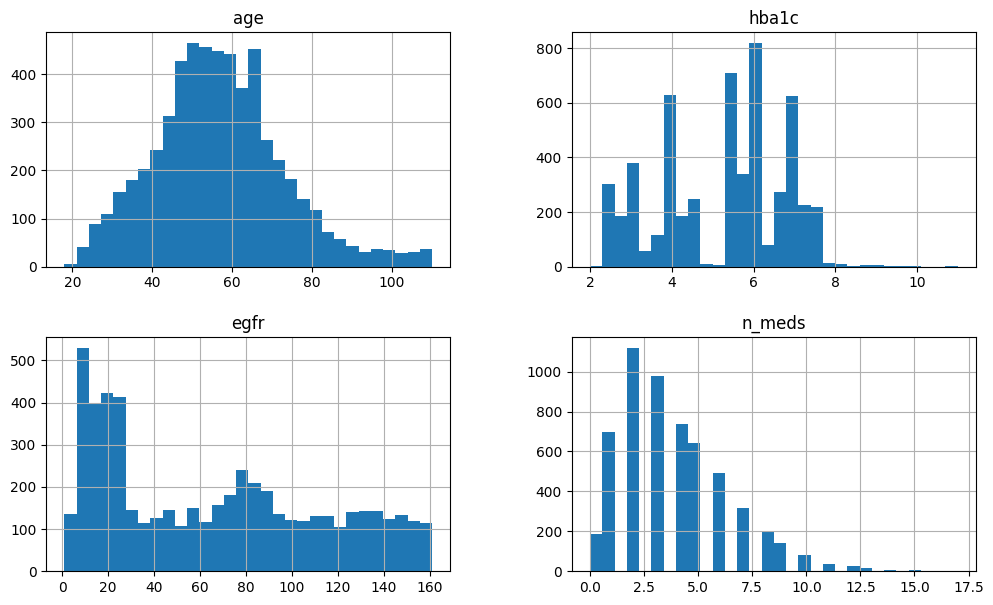

In [26]:
t2d[['age', 'hba1c', 'egfr', 'n_meds']].hist(bins=30, figsize=(12, 7))
plt.show()

In [27]:
# what share of T2D patients have each complication or drug?
t2d[['has_renal_dz', 'has_retinopathy', 'has_neuropathy', 'on_metformin', 'on_insulin']].mean().round(2)

,0
has_renal_dz,0.39
has_retinopathy,0.27
has_neuropathy,0.35
on_metformin,0.56
on_insulin,0.38


Things to notice:
- Some HbA1c values are very low and some ages are over 100. These are probably artifacts of how Synthea generates patients.
- Kidney complications, retinopathy and metformin/insulin use are all common enough that eligibility rules based on them will actually split the patients.

## 5. Preprocessing, Encoding and Scaling

### Missing values

In [28]:
# how many T2D patients have no HbA1c or eGFR on record?
t2d[['hba1c', 'egfr']].isna().sum()

,0
hba1c,227
egfr,252


Two different decisions, depending on what we are doing:
- **Trial matching:** if a lab value is missing we cannot confirm the patient qualifies, so they do **not** match. We do not fill in a guess.
- **Modeling:** we fill missing values with the median *inside the model pipeline* (Section 7), so the fill values are learned from training data only.

### Outliers

In [29]:
print('age over 100:', (t2d.age > 100).sum())
print('HbA1c below 4:', (t2d.hba1c < 4).sum())
print('eGFR below 15:', (t2d.egfr < 15).sum())

age over 100: 95
HbA1c below 4: 1433
eGFR below 15: 908


We keep all of them. Unlike an impossible birth year, these are unusual but possible values (an eGFR below 15 is severe kidney failure, which is real signal). The trial rules will filter extremes naturally, since they use ranges like "HbA1c between 7.0 and 10.5".

### Encoding and scaling

Almost nothing to do here. The yes/no flags are already binary (they become 0/1 when we hand them to the model), and there are no text categories to encode. Scaling mainly matters for logistic regression (it puts columns like distance and yes/no flags on comparable ranges). Tree models like XGBoost do not need it, so it is done inside the logistic regression pipeline in Section 7.

## 6. Eligibility Matching

Every clinical trial publishes rules for who can join (**inclusion criteria**) and who cannot (**exclusion criteria**). I picked two real type 2 diabetes trials from ClinicalTrials.gov and turned the criteria I could map to columns in our patient table into yes/no checks:

- [NCT06045221](https://clinicaltrials.gov/study/NCT06045221): Lilly (ACHIEVE-3), orforglipron vs oral semaglutide, for patients not controlled on metformin
- [NCT06660173](https://clinicaltrials.gov/study/NCT06660173): Amgen, maridebart cafraglutide, a phase 2 dose-ranging study

Neither trial is open for enrollment any more (the Lilly trial finished in 2025, and Amgen's registry entry listed its trial as active but no longer recruiting as of late 2025). So they are used here as real examples of eligibility criteria, not as live recruitment.

Each check is a True/False column. A patient is eligible only if **every** check is True. Exclusion criteria are written as "does not have X", so that True always means "passed".

Missing lab values give False, matching the decision from Section 5.

**Two checks are simplifications.**
- Both trials exclude patients with *treated or unstable* retinopathy. Our data does not say how severe or treated it is, so I exclude anyone with an active retinopathy diagnosis. That is **stricter than the real rule**.
- Trial B excludes any glucose-lowering drug other than metformin (with or without an SGLT2 inhibitor). We only have flags for metformin and insulin, so its check is "not on insulin".

In [30]:
trial_A = {
    'Age >= 18':               pt.age >= 18,
    'Has type 2 diabetes':     pt.has_t2d,
    'HbA1c 7.0-10.5%':         pt.hba1c.between(7.0, 10.5),
    'On metformin':            pt.on_metformin,
    'No retinopathy (stricter than trial)': ~pt.has_retinopathy,
    'eGFR at least 45':        pt.egfr >= 45,
}

In [31]:
trial_B = {
    'Age >= 18':                       pt.age >= 18,
    'Has type 2 diabetes':             pt.has_t2d,
    'HbA1c 7.0-10.5%':                 pt.hba1c.between(7.0, 10.5),
    'Not on insulin':                  ~pt.on_insulin,
    'eGFR at least 30':                pt.egfr >= 30,
    'No retinopathy (stricter than trial)': ~pt.has_retinopathy,
}

### The eligibility funnel

Apply the checks one at a time and count how many patients are still in.

In [32]:
def funnel(checks):
    passed = pd.Series(True, index=pt.index)
    rows = [('All patients', len(pt))]
    for name, ok in checks.items():
        passed = passed & ok                       # still passing everything so far
        rows.append((name, int(passed.sum())))
    return pd.DataFrame(rows, columns=['step', 'patients'])

In [33]:
trials = {'NCT06045221 (Lilly)': trial_A, 'NCT06660173 (Amgen)': trial_B}

for name, checks in trials.items():
    print(name)
    display(funnel(checks))

NCT06045221 (Lilly)


,step,patients
0,All patients,100000
1,Age >= 18,79312
2,Has type 2 diabetes,5693
3,HbA1c 7.0-10.5%,729
4,On metformin,155
5,No retinopathy (stricter than trial),131
6,eGFR at least 45,79


NCT06660173 (Amgen)


,step,patients
0,All patients,100000
1,Age >= 18,79312
2,Has type 2 diabetes,5693
3,HbA1c 7.0-10.5%,729
4,Not on insulin,717
5,eGFR at least 30,526
6,No retinopathy (stricter than trial),363


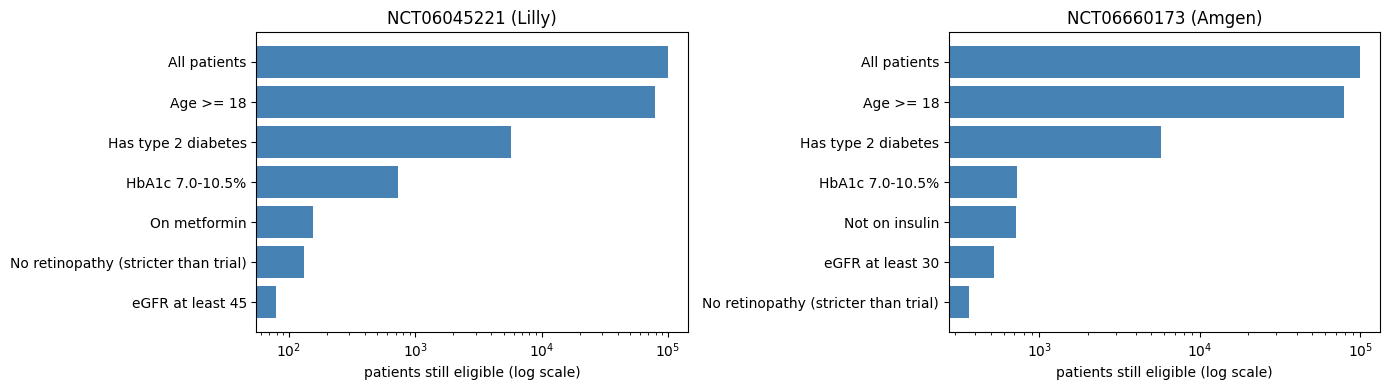

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (name, checks) in zip(axes, trials.items()):
    f = funnel(checks)
    ax.barh(f.step, f.patients, color='steelblue')
    ax.set_xscale('log')                 # log scale so the small numbers are still visible
    ax.invert_yaxis()
    ax.set_title(name)
    ax.set_xlabel('patients still eligible (log scale)')
plt.tight_layout()
plt.show()

The Lilly trial ends up with far fewer patients. Find the step with the biggest drop in its funnel. My guess is that it is the metformin step: patients whose HbA1c is in range may often not be on metformin in this data. The next cell checks that guess instead of assuming it.

In [35]:
# what are the adult T2D patients with HbA1c in the trial's range actually taking?
in_range = t2d[t2d.hba1c.between(7.0, 10.5)]
in_range[['on_metformin', 'on_insulin']].mean()

,0
on_metformin,0.212620
on_insulin,0.016461


If the share on metformin is low, that explains the drop. It would be a feature of how Synthea assigns treatment, not something we learned about real patients.

### The audit trail

For any patient we can see exactly which checks they passed or failed.

In [36]:
audit_A = pd.DataFrame(trial_A)
audit_A['eligible'] = audit_A.all(axis=1)

audit_B = pd.DataFrame(trial_B)
audit_B['eligible'] = audit_B.all(axis=1)

# a few adult T2D patients and how they did on trial A
audit_A[pt.has_t2d & (pt.age >= 18)].head(10)

,Age >= 18,Has type 2 diabetes,HbA1c 7.0-10.5%,On metformin,No retinopathy (stricter than trial),eGFR at least 45,eligible
42,True,True,False,True,False,True,False
78,True,True,False,False,True,True,False
127,True,True,False,True,True,True,False
138,True,True,True,True,False,False,False
225,True,True,False,True,True,False,False
233,True,True,False,False,True,False,False
249,True,True,False,True,True,True,False
250,True,True,False,True,True,True,False
270,True,True,False,True,False,True,False
304,True,True,False,True,False,False,False


In [37]:
eligible_A = pt[audit_A.eligible]
eligible_B = pt[audit_B.eligible]
print('Trial A eligible:', len(eligible_A))
print('Trial B eligible:', len(eligible_B))

#check: do the eligible patients respect the rules?
eligible_A[['age', 'hba1c', 'egfr', 'n_meds']].describe()

Trial A eligible: 79
Trial B eligible: 363


,age,hba1c,egfr,n_meds
count,79.000000,79.000000,79.000000,79.000000
mean,47.924051,7.749367,109.575949,2.974684
std,10.427739,0.654349,29.156198,1.476089
min,26.000000,7.000000,56.700000,1.000000
25%,40.500000,7.400000,83.500000,2.000000
50%,48.000000,7.600000,111.600000,3.000000
75%,52.500000,7.750000,132.700000,4.000000
max,82.000000,9.700000,160.300000,8.000000


### Criteria we could not use

I did not model these. Some may not exist in Synthea at all, but others (such as BMI, which Synthea records as a vital sign, and diagnosis or prescription start dates) do, so they would be natural additions. This list is taken from the registry text of each trial.

In [38]:
unmapped = {
    'NCT06045221': ['Metformin of at least 1500 mg/day, stable for 90 days',
                    'Stable body weight (within 5% for 90 days)',
                    'History of ketoacidosis or hyperosmolar state/coma in the last 6 months',
                    'NYHA class IV heart failure',
                    'Serum calcitonin of 35 ng/L or higher',
                    'Active or untreated malignancy, or a serious one in remission under 5 years',
                    'Retinopathy: only treated or planned-treatment cases are excluded (we exclude all)'],
    'NCT06660173': ['Type 2 diabetes for at least 6 months',
                    'Diet alone or a stable dose of metformin (with or without an SGLT2 inhibitor) for 3 months',
                    'BMI 23 to 50',
                    'Any glucose-lowering drug other than metformin/SGLT2 inhibitor (we only check insulin)',
                    'History of pancreatitis',
                    'Malignancy within 5 years (with some exceptions)',
                    'Heart attack, stroke or similar within 90 days, or NYHA class III-IV heart failure',
                    'Weight-affecting medications or bariatric surgery',
                    'Retinopathy: only uncontrolled or unstable cases are excluded (we exclude all)'],
}
for trial_id, items in unmapped.items():
    print(trial_id, '->', ', '.join(items))

NCT06045221 -> Metformin of at least 1500 mg/day, stable for 90 days, Stable body weight (within 5% for 90 days), History of ketoacidosis or hyperosmolar state/coma in the last 6 months, NYHA class IV heart failure, Serum calcitonin of 35 ng/L or higher, Active or untreated malignancy, or a serious one in remission under 5 years, Retinopathy: only treated or planned-treatment cases are excluded (we exclude all)
NCT06660173 -> Type 2 diabetes for at least 6 months, Diet alone or a stable dose of metformin (with or without an SGLT2 inhibitor) for 3 months, BMI 23 to 50, Any glucose-lowering drug other than metformin/SGLT2 inhibitor (we only check insulin), History of pancreatitis, Malignancy within 5 years (with some exceptions), Heart attack, stroke or similar within 90 days, or NYHA class III-IV heart failure, Weight-affecting medications or bariatric surgery, Retinopathy: only uncontrolled or unstable cases are excluded (we exclude all)


## 7. Modeling Dropout Risk

Patients who drop out of a trial cost the company time and money, so it helps to know who is at risk.

**The catch:** Synthea has no trial data, so there is no real "dropped out" column. I have to *create* one, using a rule I write down:

> dropout is more likely the **farther** a patient lives from the trial site, the **more medications** they take, and if they have **neuropathy**. On top of that there is randomness.

The model will then try to rediscover that rule. This does not prove anything about real patients. It shows the modeling workflow, and it lets us **check that the model finds what we planted**.

### Distance to the nearest trial site

In [39]:
# 4 pretend trial sites in Massachusetts (latitude, longitude)
sites = {'Boston': (42.36, -71.06), 'Worcester': (42.26, -71.80),
         'Springfield': (42.10, -72.59), 'Pittsfield': (42.45, -73.25)}

In [40]:
# approximate straight-line distance in km (good enough at this scale)
def distance_km(lat1, lon1, lat2, lon2):
    dy = (lat2 - lat1) * 111                                 # 1 degree of latitude is about 111 km
    dx = (lon2 - lon1) * 111 * np.cos(np.radians(42))        # degrees of longitude are shorter this far north
    return np.sqrt(dx**2 + dy**2)                            # Pythagoras

In [41]:
# distance from every patient to every site, then keep the closest one
dists = pd.DataFrame({name: distance_km(pt.LAT, pt.LON, lat, lon)
                      for name, (lat, lon) in sites.items()})

pt['dist_km'] = dists.min(axis=1)
pt['site'] = dists.idxmin(axis=1)
pt.dist_km.describe()

,dist_km
count,100000.000000
mean,28.220200
std,23.582774
min,0.057757
25%,10.239517
50%,22.783403
75%,38.077140
max,149.630273


### Simulating who drops out

We model every adult with type 2 diabetes.

In [42]:
# the cohort we model: every adult with type 2 diabetes (a cohort = the group of patients under study)
cohort = pt[pt.has_t2d & (pt.age >= 18)].copy()
len(cohort)

5693

In [43]:
rng = np.random.default_rng(42)     # fixed seed so the results are repeatable

# the "risk score": bigger = more likely to drop out
z = (-1.0
     + 0.03 * (cohort.dist_km - 20)                  # more risk for every extra km from the site
     + 0.25 * (cohort.n_meds - 4)                    # more risk for every extra medication
     + 0.60 * cohort.has_neuropathy.astype(float))   # more risk if they have neuropathy

In [44]:
# turn the score into a probability, then flip a weighted coin for each patient
prob = 1 / (1 + np.exp(-z))
cohort['dropout'] = (rng.random(len(cohort)) < prob).astype(int)     # 1 = dropped out

# a column of pure randomness, as a control (the model should ignore it)
cohort['noise'] = rng.normal(size=len(cohort))

print('Simulated dropout rate:', round(cohort.dropout.mean(), 3))

Simulated dropout rate: 0.382


### Train and test split

The model learns from 80% of patients and is graded on the 20% it has never seen.

In [45]:
features = ['dist_km', 'n_meds', 'has_neuropathy',                        # the ones I planted
            'age', 'hba1c', 'egfr', 'on_insulin', 'on_metformin',         # decoys
            'has_renal_dz', 'has_retinopathy', 'noise']

X = cohort[features].astype(float)     # True/False becomes 1/0
y = cohort.dropout

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

### Baseline: logistic regression

A simple model first. The pipeline fills missing values with the median and scales the columns, both learned from the training data only.

In [46]:
logit = make_pipeline(SimpleImputer(strategy='median'), StandardScaler(), LogisticRegression(max_iter=1000))
logit.fit(X_train, y_train)

print('Logistic regression AUC:', round(roc_auc_score(y_test, logit.predict_proba(X_test)[:, 1]), 3))

Logistic regression AUC: 0.705


**AUC** measures how well the model ranks patients: 0.5 is a coin flip and 1.0 is perfect. Because dropout here is partly random, no model can score close to 1.0.

### XGBoost

In [47]:
xgb = XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, subsample=0.8,
                    eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)

print('XGBoost AUC:', round(roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1]), 3))

XGBoost AUC: 0.693


The two models should score about the same. That is expected: the effects I planted are mostly straight-line, so the fancier model has nothing extra to find. On real data, with more complicated patterns, the tree model could pull ahead.

**How high could any model score?** Dropout here includes coin-flip randomness, so even someone who knew my exact rule could not predict perfectly. We can measure that ceiling by scoring the true probabilities directly (this uses all patients, so it is a rough comparison with the test-set AUCs above).

In [48]:
print('Best possible AUC (using the true probabilities):', round(roc_auc_score(cohort.dropout, prob), 3))

Best possible AUC (using the true probabilities): 0.745


If the two models land close to that number, they have found almost everything there is to find.

### Check: did the model find the rule I planted?

**Permutation importance**: shuffle one column at a time and see how much the score drops. A big drop means the model relied on that column.

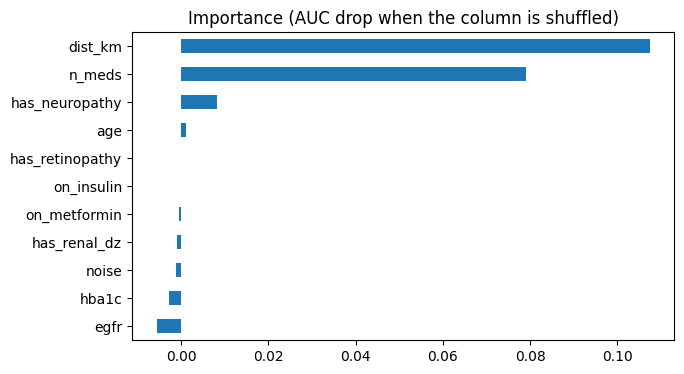

In [49]:
imp = permutation_importance(xgb, X_test, y_test, scoring='roc_auc', n_repeats=10, random_state=0)

importance = pd.Series(imp.importances_mean, index=features).sort_values()
importance.plot.barh(figsize=(7, 4))
plt.title('Importance (AUC drop when the column is shuffled)')
plt.show()

Distance and number of medications should be at the top, with neuropathy after them, and the decoys and the random-noise column near zero (tiny negative values are just wobble). If so, the model recovered the rule I wrote. That is the only thing this check proves: **the model works as intended on data where we know the answer**.

### Risk scores for eligible patients

To give every patient a fair predicted risk, each score comes from a model that never saw that patient (5-fold cross-validation).

In [50]:
cohort['risk'] = cross_val_predict(xgb, X, y, cv=5, method='predict_proba')[:, 1]

In [51]:
for name, eligible in [('NCT06045221', eligible_A), ('NCT06660173', eligible_B)]:
    risk = cohort[cohort.PATIENT.isin(eligible.PATIENT)].risk
    print(name, '| eligible:', len(risk), '| average predicted dropout risk:', round(risk.mean(), 3))

print('All adult T2D patients | average predicted dropout risk:', round(cohort.risk.mean(), 3))

NCT06045221 | eligible: 79 | average predicted dropout risk: 0.311
NCT06660173 | eligible: 363 | average predicted dropout risk: 0.292
All adult T2D patients | average predicted dropout risk: 0.381


Do eligible patients look different from the full cohort? Predicted risk depends on distance and medication count (the two main things I planted), so let's compare them directly.

In [52]:
columns = ['n_meds', 'dist_km', 'risk']
compare = pd.DataFrame({
    'All adult T2D':    cohort[columns].mean(),
    'Trial A eligible': cohort[cohort.PATIENT.isin(eligible_A.PATIENT)][columns].mean(),
    'Trial B eligible': cohort[cohort.PATIENT.isin(eligible_B.PATIENT)][columns].mean(),
})
compare.round(2)

,All adult T2D,Trial A eligible,Trial B eligible
n_meds,3.88,2.97,2.44
dist_km,28.41,26.47,26.83
risk,0.38,0.31,0.29


If the eligible groups take fewer medications or live closer on average, that is what pulls their predicted risk down. The gap between the two trials is small, so I would not read much into it.

## 8. Limitations

- **The patients are synthetic.** Synthea models diabetes realistically enough to practice on, but it is not real evidence.
- **The dropout outcome is simulated.** Synthea has no trial or dropout data, so I wrote the rule. The model finding it is a test that the workflow works, not a discovery about real patients.
- **Only some criteria are covered.** The unmodeled ones are listed in Section 6. Some (like BMI and time-based rules) could be added, because Synthea records them.
- **The retinopathy checks are stricter than the real trials' rules,** which only exclude treated or unstable cases.
- **The trials are no longer recruiting.** They serve as real examples of eligibility criteria.
- **Labs use only the latest value.** Real criteria often say things like "HbA1c within the last 3 months", which needs dates.
- **The trial sites and distances are made up.** Distance is an approximate straight line, not travel time.

**With real data, the next steps would be:** real dropout labels from past trials, time-aware features, and validation on a separate set of trials or sites.